# **MediaPipePose 3D Keypoints Stereo Distance**

## **Pipeline**
* Use MediaPipePose to get 2D keypoints (pixel coordinates) and 3D keypoints (unscaled camera coordinates)
* Use StereoSGBM to get distance from camera to shoulder joint
* Place 3D keypoints at calculated distance (camera coordinates)
* Convert 3D keypoints to Unreal Engine camera coordinates
* Render pose visualization
* Compute output vectors

### **Setup**

```
conda create -n fbv-media-pipe-pose python=3.10
conda activate fbv-media-pipe-pose
pip install mediapipe opencv-python
pip install ipympl
conda install ipykernel=6.29.5
```

In [36]:
import cv2
import numpy as np
import time

In [37]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision

In [38]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [39]:
%matplotlib widget

In [40]:
IMAGE_A_PATH = "../../../dataset/images_A/00001A.png"
IMAGE_B_PATH = "../../../dataset/images_B/00001B.png"
MODEL_PATH = "../../models/pose_landmarker_full.task"

FOCAL_LENGTH_MM = 35.0
SENSOR_WIDTH_MM = 36.0 
BASELINE_M = 0.1

### **Sample Image**

Image Shape: (1080, 1920, 3)


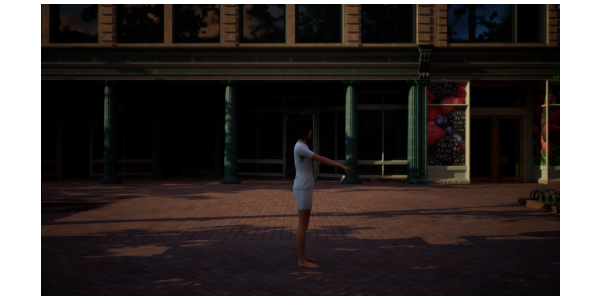

In [41]:
# Load & Preview Sample Image
image = cv2.imread(IMAGE_A_PATH)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(f"Image Shape: {image.shape}")

fig = plt.figure(figsize=(6, 3), layout="constrained")
plt.imshow(image)
plt.axis('off')
plt.show()

### **Keypoint Regression (CPU)**

In [42]:
# Create PoseLandmarker Object

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.PoseLandmarkerOptions(base_options=base_options)
detector = vision.PoseLandmarker.create_from_options(options)

In [43]:
# Detect Keypoints

start_time = time.perf_counter()

mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image)
detection_result = detector.detect(mp_image)

end_time = time.perf_counter()

execution_time = end_time - start_time
print(f"Detection took: {execution_time:.4f} seconds")
print(f"FPS: {1/execution_time:.2f}")

Detection took: 0.0284 seconds
FPS: 35.22


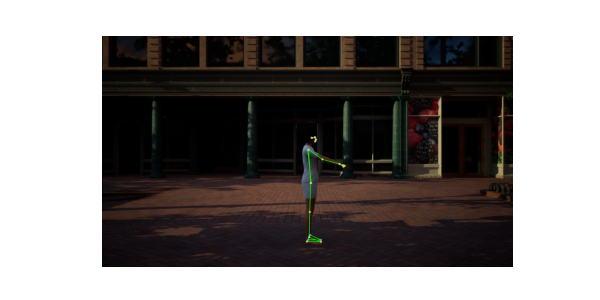

In [44]:
# Show Annotated Image (Pixel Coordinates)

# Helper Util from: https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker
def draw_landmarks_on_image(rgb_image, detection_result):
    pose_landmarks_list = detection_result.pose_landmarks
    annotated_image = np.copy(rgb_image)

    pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
    pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

    for pose_landmarks in pose_landmarks_list:
        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=pose_landmarks,
            connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
            landmark_drawing_spec=pose_landmark_style,
            connection_drawing_spec=pose_connection_style)

    return annotated_image

annotated_image = draw_landmarks_on_image(mp_image.numpy_view(), detection_result)
plt.figure(figsize=(6, 3))
plt.imshow(annotated_image)
plt.axis('off')
plt.show()

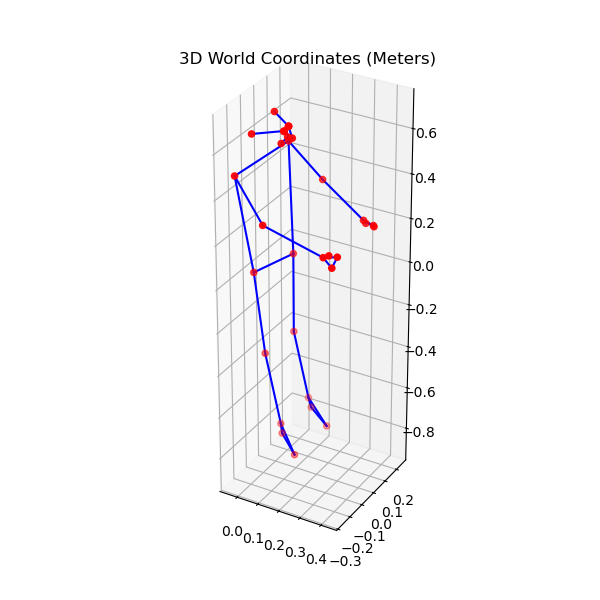

In [45]:
# Show 3D Coordinates

def plot_world_landmarks(detection_result):
    landmarks = detection_result.pose_world_landmarks[0]
    points = np.array([[lm.x, lm.y, lm.z] for lm in landmarks])

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points[:, 0], points[:, 2], -points[:, 1], c='r')

    connections = vision.PoseLandmarksConnections.POSE_LANDMARKS
    
    for connection in connections:
        start_idx = connection.start
        end_idx = connection.end
        
        ax.plot(
            [points[start_idx, 0], points[end_idx, 0]],
            [points[start_idx, 2], points[end_idx, 2]],
            [-points[start_idx, 1], -points[end_idx, 1]],
            c='b'
        )
    
    ax.set_aspect('equal')

    ax.set_title('3D World Coordinates (Meters)')
    plt.show()

plot_world_landmarks(detection_result)

### **Convert To Numpy**

In [46]:
# Create Numpy Arrays

landmarks_2d = detection_result.pose_landmarks
keypoints_2d = np.array([[lm.x, lm.y] for lm in landmarks_2d[0]]) if landmarks_2d else np.zeros((33, 2))

landmarks_3d = detection_result.pose_world_landmarks
keypoints_3d = np.array([[lm.x, lm.y, lm.z] for lm in landmarks_3d[0]]) if landmarks_3d else np.zeros((33, 3))

### **Compute Disparity Map**

In [47]:
# Load & Crop Images

image_A = cv2.imread(IMAGE_A_PATH)
image_B = cv2.imread(IMAGE_B_PATH)

gray_A_full = cv2.cvtColor(image_A, cv2.COLOR_BGR2GRAY)
gray_B_full = cv2.cvtColor(image_B, cv2.COLOR_BGR2GRAY)

In [48]:
# Crop Images

h, w = 480, 480
y_start, x_start = 300, 720

gray_A = gray_A_full[y_start:y_start+h, x_start:x_start+w]
gray_B = gray_B_full[y_start:y_start+h, x_start:x_start+w]

In [49]:
# Initialize SGBM object

stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=160,
    blockSize=5,
    P1=8 * 3 * 5**2,
    P2=32 * 3 * 5**2,
    disp12MaxDiff=1,
    uniquenessRatio=15,
    speckleWindowSize=0,
    speckleRange=2,
    preFilterCap=63,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
)

In [50]:
# Compute Disparity

start_time = time.perf_counter()

disparity = stereo.compute(gray_A, gray_B).astype(np.float32) / 16.0

end_time = time.perf_counter()

execution_time = end_time - start_time
print(f"Disparity took: {execution_time:.4f} seconds")
print(f"FPS: {1/execution_time:.2f}")

Disparity took: 0.0084 seconds
FPS: 119.45


### **Calculate Camera-Shoulder Distnace**

In [51]:
# Get Predicted Right Shoulder Pixel Location

height, width = disparity.shape

shoulder_kp_2d = keypoints_2d[12]

px_x = int(np.clip(shoulder_kp_2d[0] * width, 0, width - 1))
px_y = int(np.clip(shoulder_kp_2d[1] * height, 0, height - 1))

window = disparity[px_y-2:px_y+3, px_x-2:px_x+3]
disp_at_shoulder = np.nanmedian(window) if np.any(window) else 0

print(disp_at_shoulder)

31.0


In [52]:
# Calculate Focal Length

image_width_px = w
focal_length_px = (FOCAL_LENGTH_MM * image_width_px) / SENSOR_WIDTH_MM

In [53]:
# Distance Output

distance = None
if disp_at_shoulder > 0:
    distance = (focal_length_px * BASELINE_M) / disp_at_shoulder
    print(f"Distance to shoulder: {distance:.3f} meters")
else:
    print("Distance calculation failed: Disparity is zero or negative at center.")

Distance to shoulder: 1.505 meters


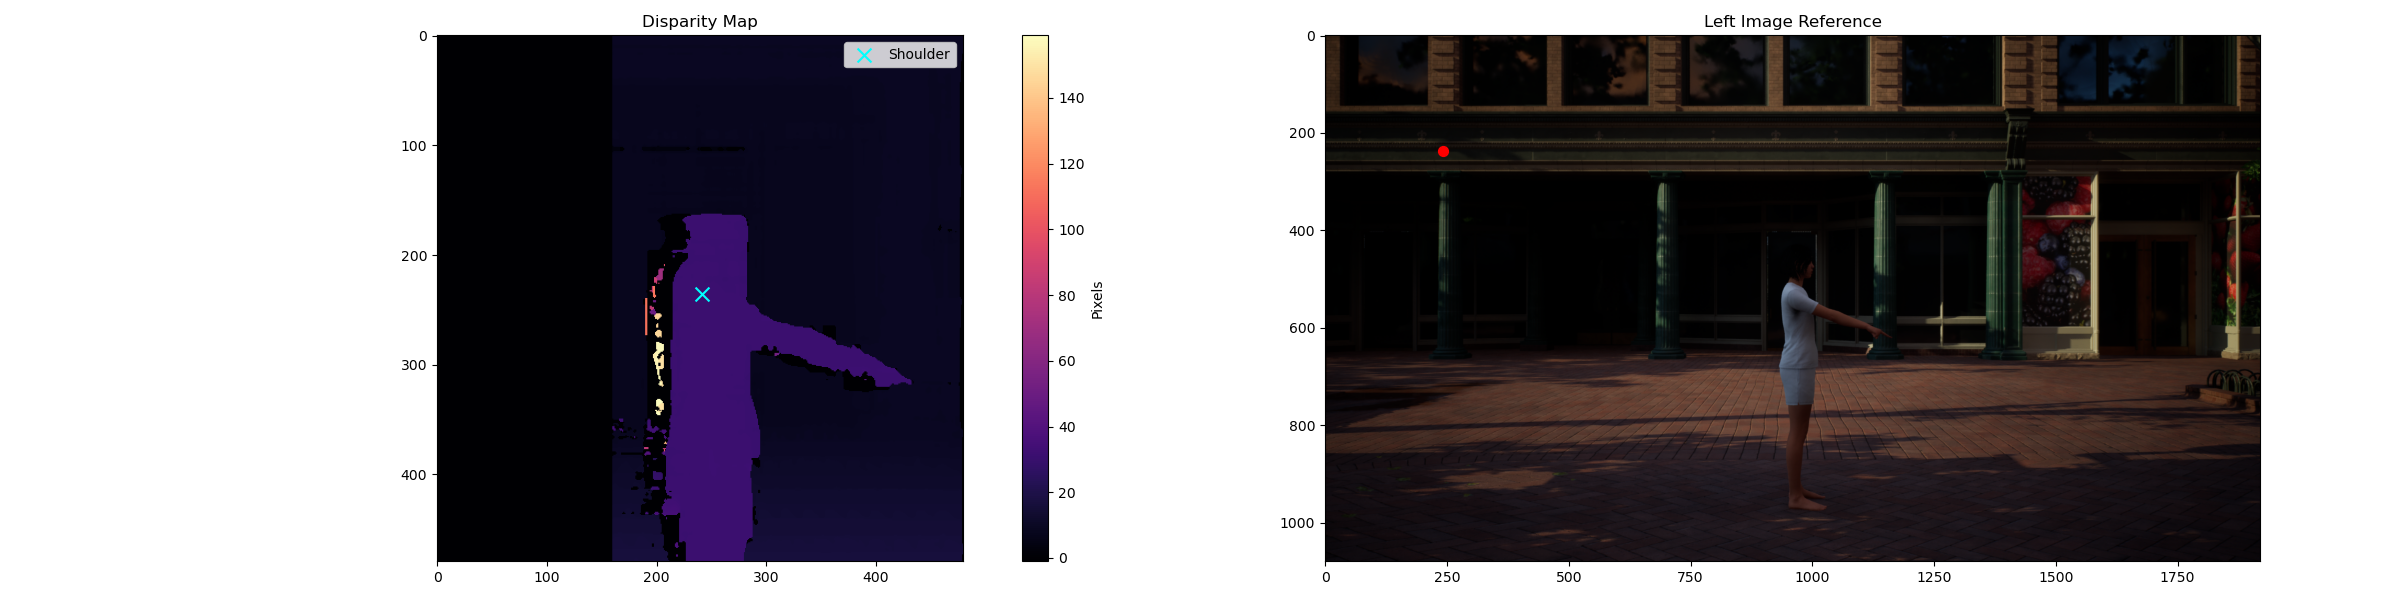

In [54]:
# Visualize Disparity

plt.figure(figsize=(24, 6))

plt.subplot(1, 2, 1)
plt.title("Disparity Map")
plt.imshow(disparity, cmap='magma')
plt.colorbar(label='Pixels')
plt.scatter(px_x, px_y, color='cyan', marker='x', s=100, label='Shoulder')
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Left Image Reference")
plt.imshow(cv2.cvtColor(image_A, cv2.COLOR_BGR2RGB))
plt.scatter(px_x, px_y, color='red', marker='o', s=50)

plt.tight_layout()
plt.show()

### **Place 3D Keypoints**

In [55]:
# Transform 3D Keypoints Given Distance

keypoints_3d_rel = keypoints_3d - keypoints_3d[12]
transformed_keypoints_3d = keypoints_3d_rel.copy()
transformed_keypoints_3d[:, 2] += distance

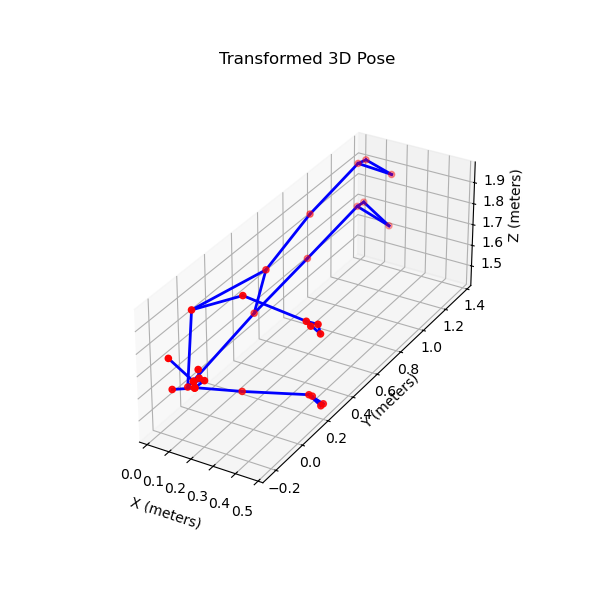

In [56]:
# Visualize Transformed 3D Keypoints

def plot_pose_3d(points_3d):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], c='r', marker='o')

    for connection in vision.PoseLandmarksConnections.POSE_LANDMARKS:
        start_idx, end_idx = connection.start, connection.end
        if start_idx < len(points_3d) and end_idx < len(points_3d):
            xs = [points_3d[start_idx, 0], points_3d[end_idx, 0]]
            ys = [points_3d[start_idx, 1], points_3d[end_idx, 1]]
            zs = [points_3d[start_idx, 2], points_3d[end_idx, 2]]
            ax.plot(xs, ys, zs, c='b', linewidth=2)

    ax.set_aspect('equal')
    ax.set_xlabel('X (meters)')
    ax.set_ylabel('Y (meters)')
    ax.set_zlabel('Z (meters)')
    ax.set_title('Transformed 3D Pose')
    
    plt.show()

plot_pose_3d(transformed_keypoints_3d)

### **Convert To Unreal Engine Coordinates**

In [57]:
# Apply Coordinate Conversion

def convert_to_unreal_coords(points_3d_meters):
    unreal_pts = np.zeros_like(points_3d_meters)
    
    # UE X (Forward) = CV Z
    unreal_pts[:, 0] = points_3d_meters[:, 2] * 100
    
    # UE Y (Right) = CV X
    unreal_pts[:, 1] = points_3d_meters[:, 0] * 100
    
    # UE Z (Up) = -CV Y
    unreal_pts[:, 2] = -points_3d_meters[:, 1] * 100
    
    return unreal_pts

ue_keypoints_3d = convert_to_unreal_coords(transformed_keypoints_3d)

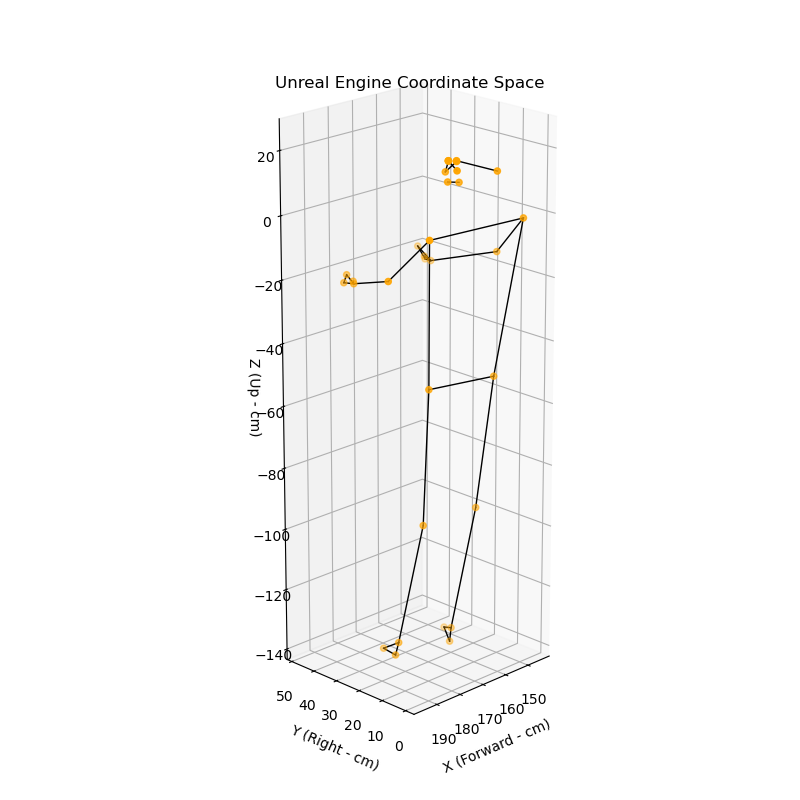

In [58]:
# Verify Coordinate Conversion

def plot_pose_unreal_3d(points_3d):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], c='orange', marker='o')

    for connection in vision.PoseLandmarksConnections.POSE_LANDMARKS:
        start_idx, end_idx = connection.start, connection.end
        if start_idx < len(points_3d) and end_idx < len(points_3d):
            xs = [points_3d[start_idx, 0], points_3d[end_idx, 0]]
            ys = [points_3d[start_idx, 1], points_3d[end_idx, 1]]
            zs = [points_3d[start_idx, 2], points_3d[end_idx, 2]]
            ax.plot(xs, ys, zs, c='black', linewidth=1)

    ax.set_xlabel('X (Forward - cm)')
    ax.set_ylabel('Y (Right - cm)')
    ax.set_zlabel('Z (Up - cm)')
    ax.set_title('Unreal Engine Coordinate Space')

    ax.set_aspect('equal')
    ax.invert_yaxis()
    
    ax.view_init(elev=20, azim=45)
    
    plt.show()

plot_pose_unreal_3d(ue_keypoints_3d)

### **Compute Output Vector**

In [59]:
# Given Constants

camera_coords = np.array([0, 0, 0])
world_up = np.array([0, 0, 1])
camera_pitch_rad = np.deg2rad(-0)

In [60]:
# Get Right Shoulder & Wrist Coordinates

shoulder_coords = ue_keypoints_3d[12]
wrist_coords = ue_keypoints_3d[16]

print(shoulder_coords)
print(wrist_coords)

[150.5376339   0.         -0.       ]
[147.39290476  41.56709053 -23.26197028]


In [61]:
# Shoulder-Camera Distance

distance = np.linalg.norm(shoulder_coords)
print(distance, "cm")

150.53763389587402 cm


In [62]:
# Shoulder-Wrist Shoulder-Camera Vectors

shoulder_wrist = wrist_coords - shoulder_coords
shoulder_wrist /= np.linalg.norm(shoulder_wrist)

shoulder_camera = camera_coords - shoulder_coords
shoulder_camera /= np.linalg.norm(shoulder_camera)

print(shoulder_wrist)
print(shoulder_camera)

[-0.06587599  0.87075006 -0.48729323]
[-1.  0.  0.]


In [63]:
# Angular Separation

angular_separation_rad = np.arccos(np.clip(np.dot(shoulder_wrist, shoulder_camera), -1.0, 1.0))
angular_separation_deg = np.rad2deg(angular_separation_rad)

print(angular_separation_deg, "deg")


86.22284875029656 deg


In [64]:
# Camera Un-Pitch Matrix (Aligns Z-Axis with Gravity)

c, s = np.cos(-camera_pitch_rad), np.sin(-camera_pitch_rad)
unpitch_matrix = np.array([
    [c,  0, s],
    [0,  1, 0],
    [-s, 0, c]
])
print(unpitch_matrix)

[[ 1.  0. -0.]
 [ 0.  1.  0.]
 [ 0.  0.  1.]]


In [65]:
# Un-Pitch Vectors

shoulder_wrist_gravity = unpitch_matrix @ shoulder_wrist
shoulder_wrist_gravity /= np.linalg.norm(shoulder_wrist_gravity)

shoulder_camera_gravity = unpitch_matrix @ shoulder_camera
shoulder_camera_gravity /= np.linalg.norm(shoulder_camera_gravity)

print(shoulder_wrist_gravity)
print(shoulder_camera_gravity)

[-0.06587599  0.87075006 -0.48729323]
[-1.  0.  0.]


In [66]:
# Yaw & Pitch Components

shoulder_wrist_gravity_yaw = np.rad2deg(np.atan2(shoulder_wrist_gravity[1], shoulder_wrist_gravity[0]))
shoulder_wrist_gravity_pitch = np.rad2deg(np.asin(np.clip(shoulder_wrist_gravity[-1], -1.0, 1.0)))

shoulder_camera_gravity_yaw = np.rad2deg(np.atan2(shoulder_camera_gravity[1], shoulder_camera_gravity[0]))
shoulder_camera_gravity_pitch = np.rad2deg(np.asin(np.clip(shoulder_camera_gravity[-1], -1.0, 1.0)))

delta_yaw = (shoulder_wrist_gravity_yaw - shoulder_camera_gravity_yaw + 180) % 360 - 180
delta_pitch = shoulder_wrist_gravity_pitch - shoulder_camera_gravity_pitch

print(delta_yaw)
print(delta_pitch)

-85.67356956010777
-29.162828346135324
